Step 1: Generating Dataset...
CSV File 'employee_salary_dataset.csv' created!

✅ Linear Regression MSE: 0.00
✅ Logistic Regression Accuracy: 92.50%
✅ Random Forest MSE: 9063626.25

Generating Graphs...


/tmp/ipykernel_10667/1338594927.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Salary_Category', data=df, palette='magma', order=['Low', 'Medium', 'High'])


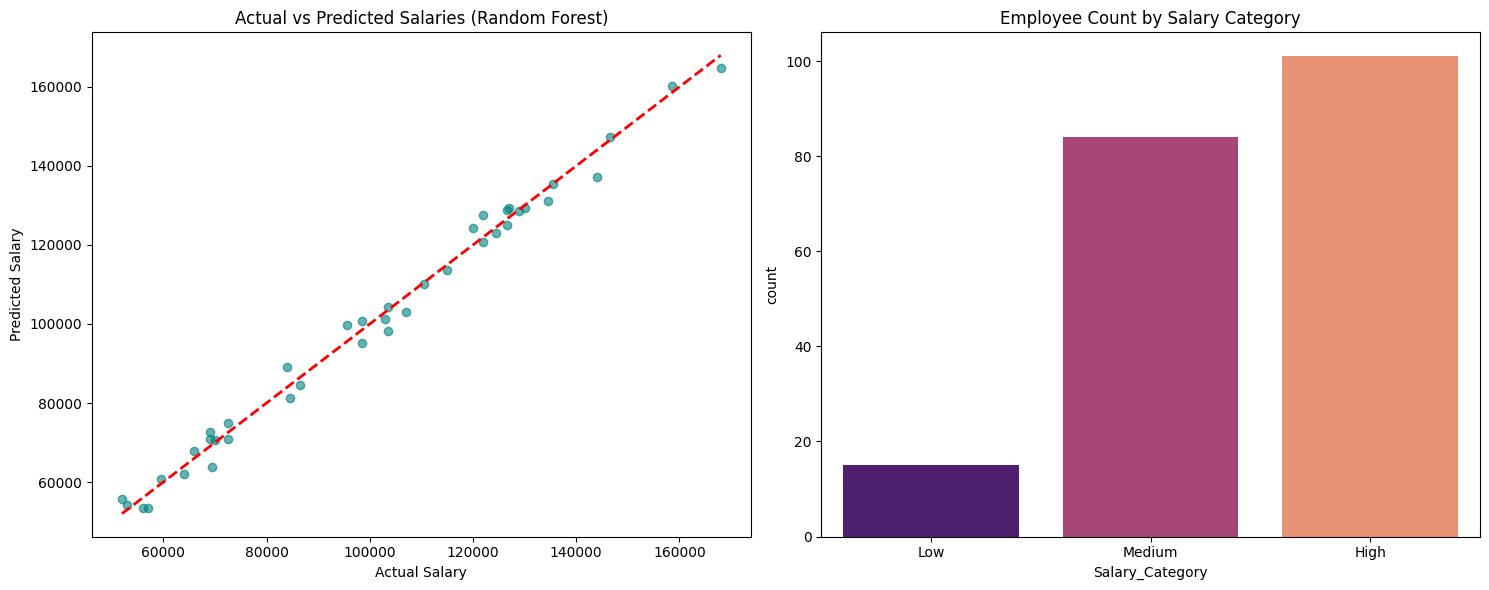

In [9]:
# 1. Necessary Libraries Import pannuvom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score
import pickle

# --- STEP 1: DATASET GENERATION (Colab-la CSV create panna) ---
print("Step 1: Generating Dataset...")
np.random.seed(42)
data = {
    'Years_Experience': np.random.randint(1, 20, 200),
    'Education_Level': np.random.randint(1, 4, 200), # 1: Bachelor, 2: Master, 3: PhD
    'Age': np.random.randint(22, 60, 200),
}
# Salary calculation logic
data['Salary'] = (data['Years_Experience'] * 5000) + (data['Education_Level'] * 10000) + (data['Age'] * 500) + 15000
df = pd.DataFrame(data)
df.to_csv('employee_salary_dataset.csv', index=False)
print("CSV File 'employee_salary_dataset.csv' created!\n")

# --- STEP 2: DATA PREPARATION ---
# Salary Category Classification-ku logic
def classify_salary(sal):
    if sal < 60000: return 'Low'
    elif sal < 100000: return 'Medium'
    else: return 'High'

df['Salary_Category'] = df['Salary'].apply(classify_salary)

# Features and Targets
X = df[['Years_Experience', 'Education_Level', 'Age']]
y_reg = df['Salary']          # Regression
y_clf = df['Salary_Category']  # Classification

# Data Split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# --- STEP 3: MODEL TRAINING ---

# A. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)
lr_preds = lr_model.predict(X_test)
print(f"✅ Linear Regression MSE: {mean_squared_error(y_test_reg, lr_preds):.2f}")

# B. Logistic Regression (Classification)
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_clf, y_train_clf)
log_preds = log_model.predict(X_test_clf)
print(f"✅ Logistic Regression Accuracy: {accuracy_score(y_test_clf, log_preds) * 100:.2f}%")

# C. Random Forest (Better Performance)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_reg)
rf_preds = rf_model.predict(X_test)
print(f"✅ Random Forest MSE: {mean_squared_error(y_test_reg, rf_preds):.2f}")

# --- STEP 4: VISUALIZATION ---
print("\nGenerating Graphs...")
plt.figure(figsize=(15, 6))

# Graph 1: Actual vs Predicted (Random Forest)
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, rf_preds, color='teal', alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salaries (Random Forest)')

# Graph 2: Salary Categories Distribution
plt.subplot(1, 2, 2)
sns.countplot(x='Salary_Category', data=df, palette='magma', order=['Low', 'Medium', 'High'])
plt.title('Employee Count by Salary Category')

plt.tight_layout()
plt.show()